# Netflix Stock Price Prediction with LSTM

In [ ]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta
import plotly.graph_objects as go

# 1. download clean data (Ensuring no MultiIndex issues)
# 'auto_adjust=True' and 'v2' logic ensures a simpler table
df = yf.download('NFLX', period='3y', interval='1d', progress=False) # Defines the historical time range you want to retrieve.
                                                                      #1d (1 day), 6mo (6 month), 1y (1 year), max (all available data).

# 2. Force flatten the table (The "Scorched Earth" Fix)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1) # Kill the 'NFLX' header row

df = df.reset_index() # Move 'Date' from the side to a real column
print(df.tail())

# 3. Use only the last 365 days so candles are thick and visible
df_plot = df.tail(365)

# 4. Create the Candlestick
figure = go.Figure(data=[go.Candlestick(
    x=df_plot['Date'],
    open=df_plot['Open'],
    high=df_plot['High'],
    low=df_plot['Low'],
    close=df_plot['Close']
)])

figure.update_layout(
    title="Netflix Stock Price (Daily Candlesticks)",
    xaxis_rangeslider_visible=False,
    template="plotly_white"
)

figure.show()

/tmp/ipykernel_41641/2812519625.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('NFLX', period='3y', interval='1d', progress=False) # Defines the historical time range you want to retrieve.


Price       Date      Close       High        Low       Open    Volume
746   2026-03-24  90.919998  93.739998  90.820000  92.790001  28938000
747   2026-03-25  92.279999  92.519997  91.239998  91.709999  29545600
748   2026-03-26  93.320000  95.860001  91.010002  91.519997  59522000
749   2026-03-27  93.430000  95.580002  92.739998  94.570000  44590700
750   2026-03-30  92.970001  94.489998  92.220001  92.750000  31393700


In [ ]:
correlation = df.corr()
print(correlation["Close"].sort_values(ascending=False))

Price
Close     1.000000
Low       0.999616
High      0.999531
Open      0.998909
Date      0.886819
Volume   -0.241848
Name: Close, dtype: float64


## Training LSTM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

x = df[["Open", "High", "Low", "Volume"]]
y = df["Close"]
x = x.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

# Initialize and fit the scaler for features (X)
scaler_x = MinMaxScaler(feature_range=(0, 1))
x_scaled_2d = scaler_x.fit_transform(x) # Scale x in 2D

# Initialize and fit the scaler for target (Y)
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y)

# Reshape scaled x to be 3D for LSTM input (samples, timesteps, features)
x_scaled_3d = x_scaled_2d.reshape(x_scaled_2d.shape[0], x_scaled_2d.shape[1], 1)

xtrain, xtest, ytrain, ytest = train_test_split(x_scaled_3d, y_scaled, # Use y_scaled for training
                                                test_size=0.2,
                                                random_state=42)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# LSTM neural network architecture
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(xtrain.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0027
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0012
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 6.7752e-04
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.1863e-04
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.2819e-04
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 6.9486e-04
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 5.2982e-04
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.6657e-04
Epoch 9/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.9748e-04
Epoch 10/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.9938e-04
Epoch 11/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.3295e-04
Epoch 12/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.0381e-04
Epoch 13/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.2029e-04
Epoch 14/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.8265e-04
Epoch 15/

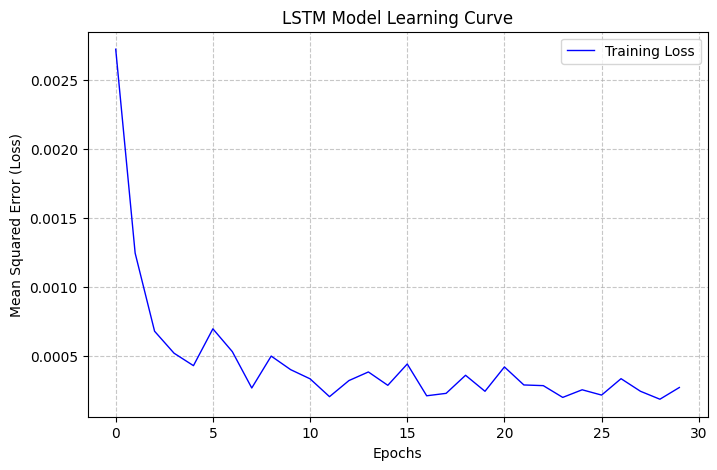

In [ ]:
import matplotlib.pyplot as plt

model.compile(optimizer='adam', loss='mean_squared_error')

# Capture the history during training
history = model.fit(xtrain, ytrain, batch_size=1, epochs=30)

# Extract loss values
loss_values = history.history['loss']

# Plot the Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(loss_values, label='Training Loss', color='blue', linewidth=1)
plt.title('LSTM Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Predict single day

In [ ]:
import numpy as np

# Select the 4 values (Open, High, Low, Volume) from the latest row
# Using .iloc[-1] gets the very last day in your data
latest_row = df[["Open", "High", "Low", "Volume"]].iloc[-1].to_numpy()

# Reshape to (1, 4, 1) to match the model's expected 3D input (batch_size, timesteps, features)
real_features = latest_row.reshape(1, 4, 1).astype('float32')

# print(real_features)
# print(type(real_features))
# print(real_features.shape)

# Predict
model.predict(real_features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[1.4957771]], dtype=float32)

## 14-Day Forecasting

In [ ]:
import numpy as np

# scaler_x and scaler_y are now defined and fitted in cell 9blHGRPU5j1p

# Get the initial input features (Open, High, Low, Volume) from the last known actual day
current_unscaled_features = df[['Open', 'High', 'Low', 'Volume']].iloc[-1].values.reshape(1, -1)

future_predictions_14_days = []

# Get the last actual Open, High, Low, Volume to calculate deltas
last_actual_open = df['Open'].iloc[-1]
last_actual_high = df['High'].iloc[-1]
last_actual_low = df['Low'].iloc[-1]
last_actual_volume = df['Volume'].iloc[-1]

# Calculate deltas from the last actual day
high_delta = last_actual_high - last_actual_open
low_delta = last_actual_open - last_actual_low # This should be a positive value

for i in range(14):
    # Scale the current unscaled features for prediction
    current_features_scaled = scaler_x.transform(current_unscaled_features)
    # Reshape to (1, 4, 1) for model input
    current_batch_for_prediction = current_features_scaled.reshape(1, 4, 1).astype('float32')

    # Predict the Close price (this prediction will be in the scaled range)
    current_pred_scaled = model.predict(current_batch_for_prediction, verbose=0) # current_pred_scaled shape (1, 1)

    # Inverse transform the prediction to get the actual price
    predicted_close = scaler_y.inverse_transform(current_pred_scaled)[0, 0]

    # Store the predicted Close price
    future_predictions_14_days.append(predicted_close)

    # Prepare features for the next day's prediction (unscaled)
    next_day_simulated_features_unscaled = np.zeros((1, 4))
    next_day_simulated_features_unscaled[0, 0] = predicted_close # Open = Predicted Close (actual price)
    next_day_simulated_features_unscaled[0, 1] = predicted_close + high_delta # High = Predicted Close + historical delta
    next_day_simulated_features_unscaled[0, 2] = predicted_close - low_delta # Low = Predicted Close - historical delta
    next_day_simulated_features_unscaled[0, 3] = last_actual_volume # Volume = Last actual Volume (constant for simplicity)

    # Update `current_unscaled_features` for the next iteration
    current_unscaled_features = next_day_simulated_features_unscaled.copy()

print(future_predictions_14_days)

[np.float32(93.04101), np.float32(93.331696), np.float32(93.622), np.float32(93.911865), np.float32(94.201225), np.float32(94.49003), np.float32(94.77819), np.float32(95.06565), np.float32(95.352356), np.float32(95.638214), np.float32(95.923164), np.float32(96.20712), np.float32(96.49002), np.float32(96.77178)]


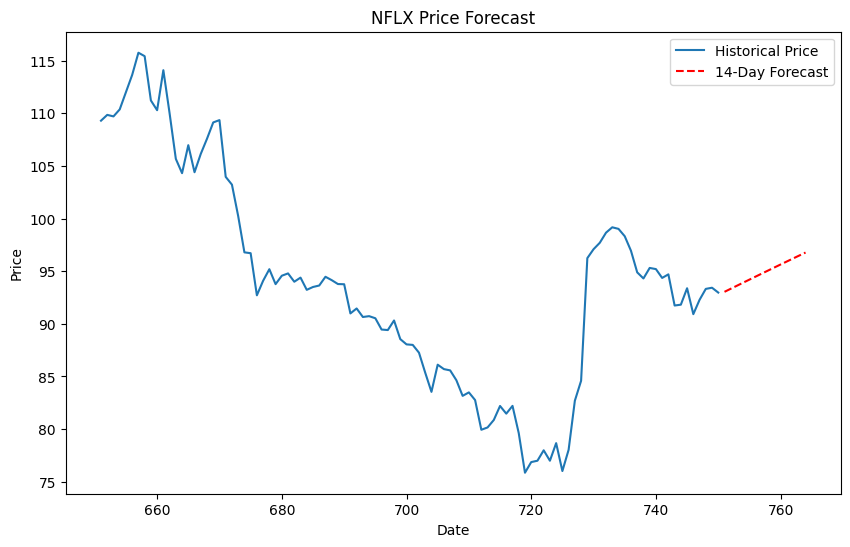

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

plt.figure(figsize=(10, 6))
# Plot last 100 days of real data
plt.plot(df.index[-100:], df['Close'].tail(100), label='Historical Price')
# Plot 14 days of future data
future_indices = np.arange(len(df), len(df) + len(future_predictions_14_days))
plt.plot(future_indices, future_predictions_14_days, label='14-Day Forecast', color='red', linestyle='--')
plt.title('NFLX Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()